In [9]:

# with open("../data/mfpt-pace=25000-new-ref.pkl", "rb") as f:
#     all_mfpt = pickle.load(f)
    
# thresholds = np.array(list(all_mfpt['chignolin'].keys()))
# df = collect_df(True, all_mfpt, thresholds[1])

# mfpt = df['mfpt']
# y = np.log(mfpt['WT'] / mfpt.drop(labels=["WT"], errors="ignore"))

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from common.colvar_utils import read_colvar_header_names, load_colvar
from common.hlda_utils import (
    hlda_from_moments,
    bin_sufficient_stats,
    aggregate_moments,
    centers_from_edges,
    prune,
)

base_dir = Path("../data/traj")
f_filename = "COLVAR_CV_F"
uf_filename = "COLVAR_CV_UF"
sample_n = 1000000
n_bins = 200

tF_grid = np.round(np.linspace(0.18, 0.50, 10), 2)
tU_grid = np.round(np.linspace(0.3, 0.79, 10), 2)

wildtype_alias = {"Wildtype": "WT"}


weights_rows = {}
lambda_tbl = []

for protein_dir in sorted(d for d in base_dir.iterdir() if d.is_dir()):
    short = protein_dir.name
    if short in ["T7Q", "P3R"]:
        continue
    
    f_path, uf_path = protein_dir / f_filename, protein_dir / uf_filename
    if not (f_path.exists() and uf_path.exists()):
        continue

    names = read_colvar_header_names(f_path)
    desc_cols = [c for c in names if c.startswith("d")]

    if "rmsd_ca" not in names:
        continue

    usecols = desc_cols + ["rmsd_ca"]

    df_F = load_colvar(f_path, usecols, sample_n)
    df_UF = load_colvar(uf_path, usecols, sample_n)

    print(f"{short}: initial descriptors = {len(desc_cols)}")

    eF, cF, sF, S2F = bin_sufficient_stats(df_F, desc_cols, "rmsd_ca", n_bins)
    eU, cU, sU, S2U = bin_sufficient_stats(df_UF, desc_cols, "rmsd_ca", n_bins)

    cF_cent = centers_from_edges(eF)
    cU_cent = centers_from_edges(eU)

    for tF in tF_grid:
        mask_F = cF_cent <= tF
        if cF[mask_F].sum() == 0:
            continue

        muA, SA, nA = aggregate_moments(cF, sF, S2F, mask_F)
        if nA is None or nA < 2:
            continue

        for tU in tU_grid:
            if tU <= tF:
                continue

            mask_U = cU_cent >= tU
            if cU[mask_U].sum() == 0:
                continue

            muB, SB, nB = aggregate_moments(cU, sU, S2U, mask_U)
            if nB is None or nB < 2:
                continue

            pooled_cov = ((nA - 1) * SA + (nB - 1) * SB) / (nA + nB - 2)

            desc_cols_kept, keep_idx = prune(SA, SB, desc_cols, threshold=0.93)
    

            muA_red = muA[keep_idx]
            SA_red = SA[np.ix_(keep_idx, keep_idx)]
            muB_red = muB[keep_idx]
            SB_red = SB[np.ix_(keep_idx, keep_idx)]

   
            _, lam = hlda_from_moments(muA_red, SA_red, muB_red, SB_red, desc_cols_kept)
      
            key = (short, float(tF), float(tU))

            print(
                f"{short}: tF={tF:.2f}, tU={tU:.2f}, nA={nA}, nB={nB}, "
                f"n_desc={len(desc_cols_kept)}, lambda={lam:.4f}"
            )

            lambda_tbl.append(
                {
                    "Mutant": short,
                    "tF": float(tF),
                    "tU": float(tU),
                    "lambda": lam,
                    "n_desc": len(desc_cols_kept),
                }
            )

lambda_df = pd.DataFrame(lambda_tbl)


D2A: initial descriptors = 28
  prune_one: dropping d26 with rho=0.976
  prune_one: dropping d27 with rho=0.974
  prune_one: dropping d28 with rho=0.969
  prune_one: dropping d29 with rho=0.965
  prune_one: dropping d25 with rho=0.962
  prune_one: dropping d09 with rho=0.946
  prune_one: dropping d19 with rho=0.942
D2A: tF=0.18, tU=0.30, nA=8861, nB=91951, n_desc=21, lambda=5955.2832
  prune_one: dropping d26 with rho=0.976
  prune_one: dropping d27 with rho=0.974
  prune_one: dropping d28 with rho=0.969
  prune_one: dropping d29 with rho=0.965
  prune_one: dropping d25 with rho=0.962
  prune_one: dropping d09 with rho=0.945
  prune_one: dropping d19 with rho=0.941
D2A: tF=0.18, tU=0.35, nA=8861, nB=91356, n_desc=21, lambda=6036.7635
  prune_one: dropping d26 with rho=0.975
  prune_one: dropping d28 with rho=0.971
  prune_one: dropping d27 with rho=0.970
  prune_one: dropping d29 with rho=0.968
  prune_one: dropping d25 with rho=0.964
  prune_one: dropping d09 with rho=0.936
  prune_on

MFPT thresholds in PKL: [0.28, 0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5]


/tmp/ipykernel_445650/367560149.py:182: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(tm_corr_stats)


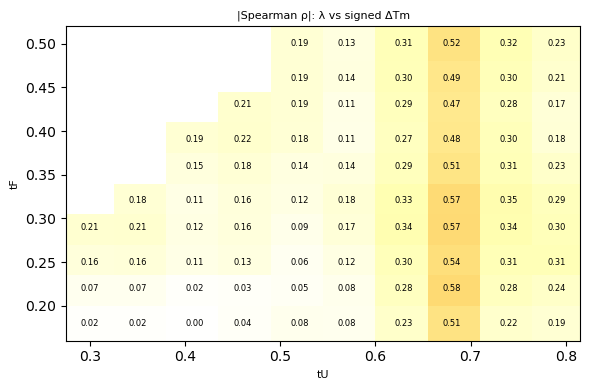

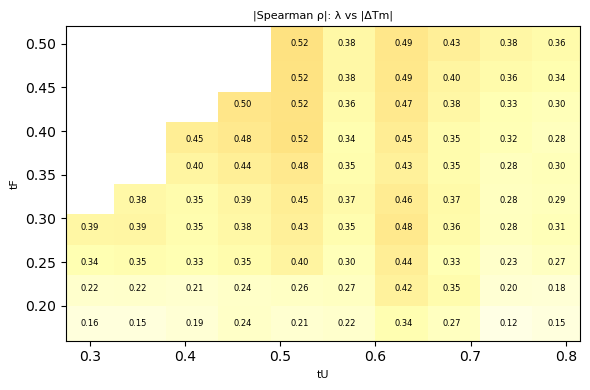

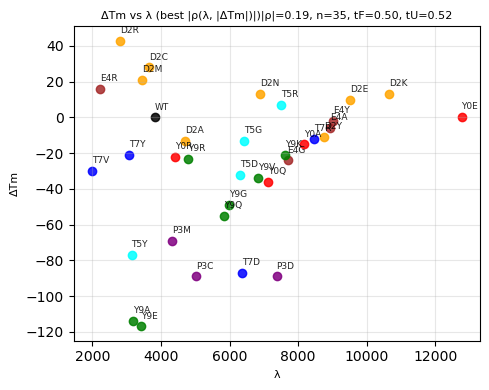

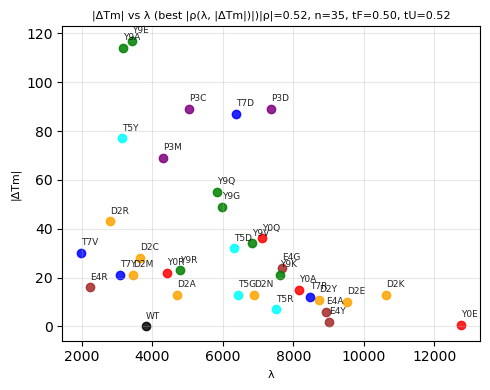

[best Tm] tF=0.500, tU=0.520, |ρ_signed|=0.191, |ρ_absTm|=0.520, n=35


/tmp/ipykernel_445650/367560149.py:292: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_445650/367560149.py:292: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_445650/367560149.py:292: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping co

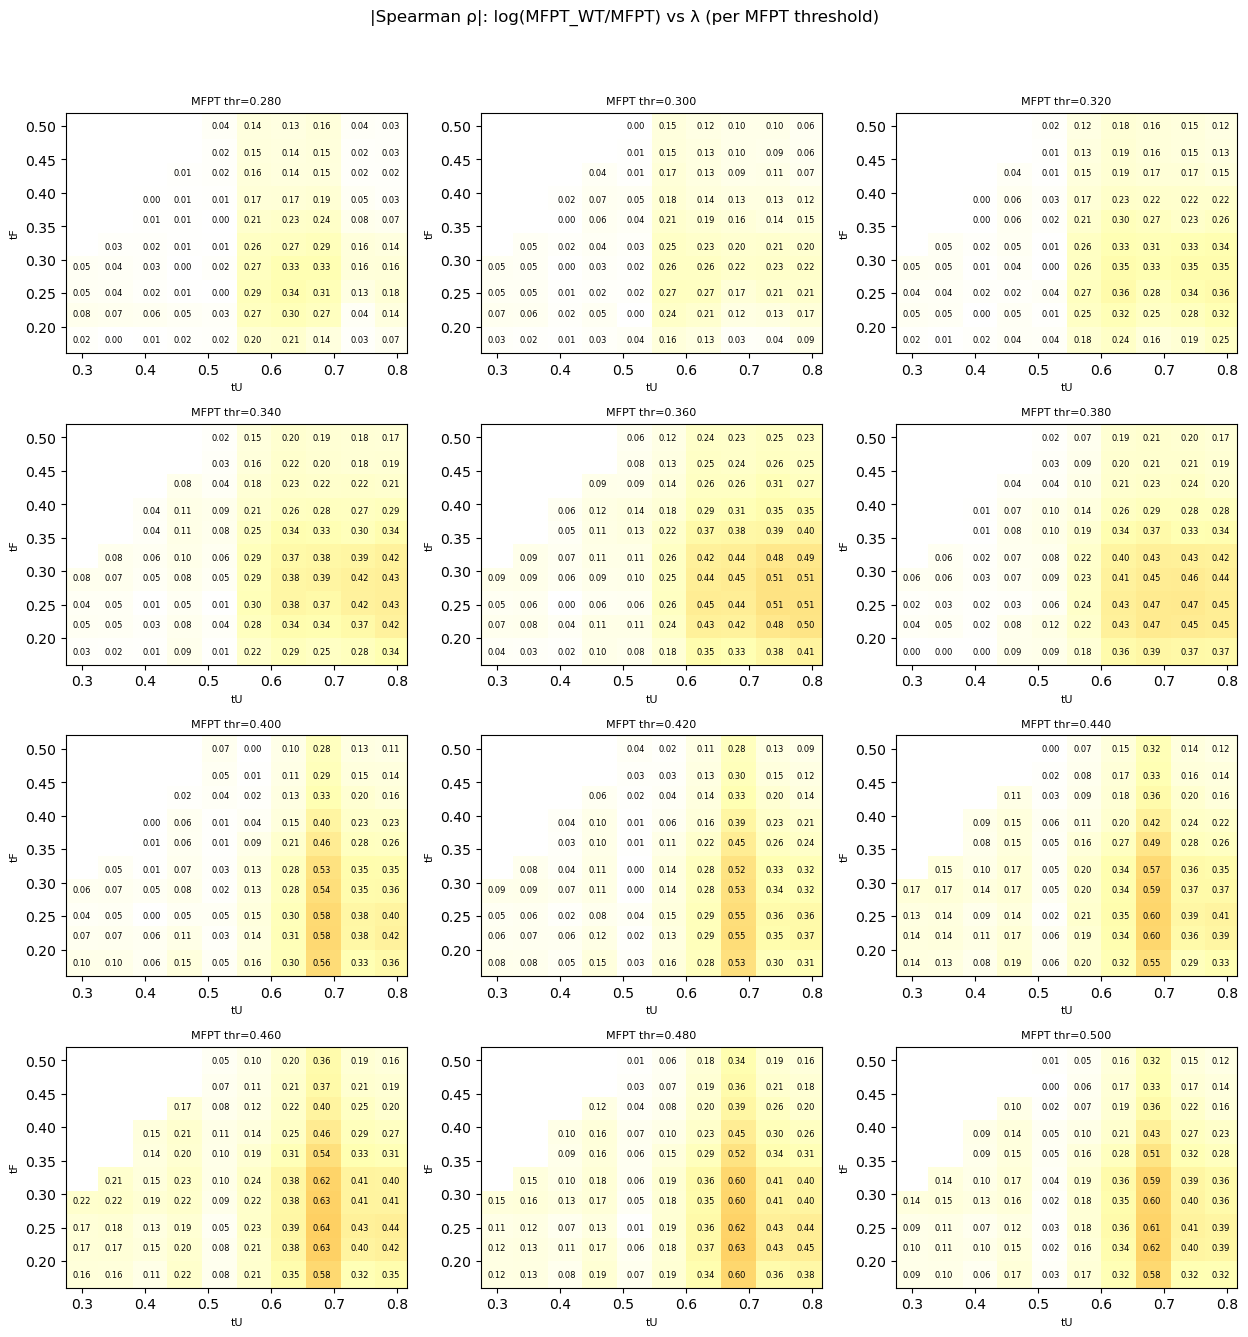

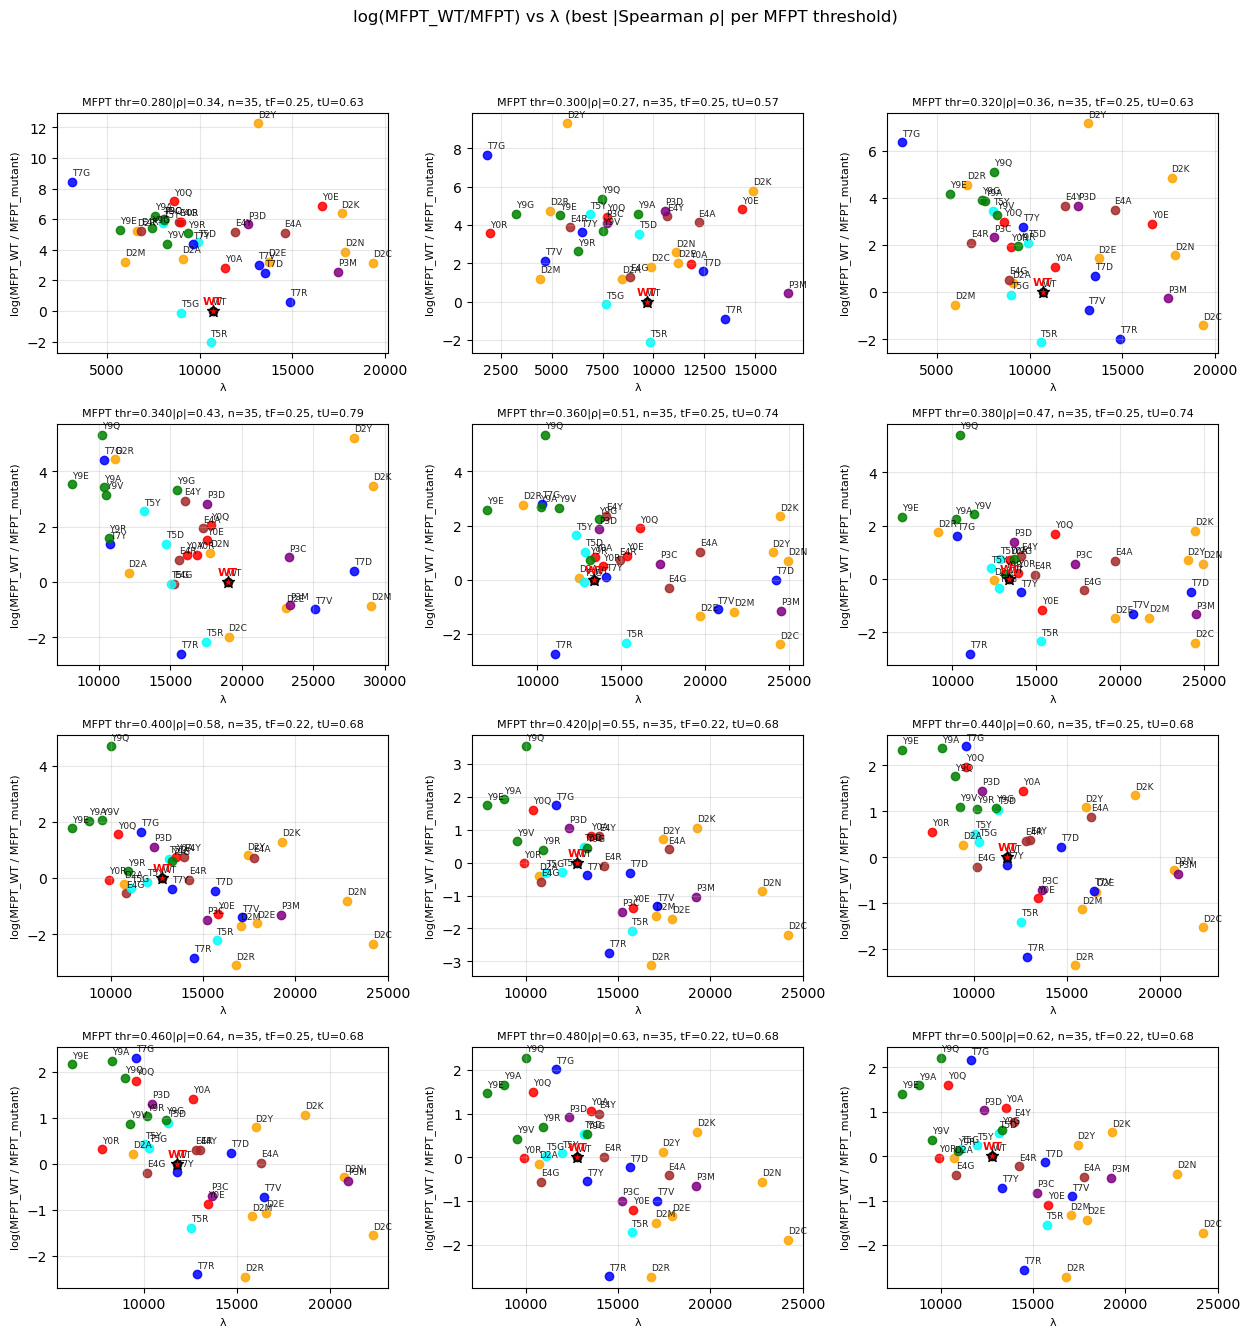


Best MFPT points per threshold:
    threshold    tF    tU  rho_spearman   n
0        0.28  0.25  0.63      0.338375  35
1        0.30  0.25  0.57      0.267507  35
2        0.32  0.25  0.63      0.359384  35
3        0.34  0.25  0.79      0.431653  35
4        0.36  0.25  0.74      0.512885  35
5        0.38  0.25  0.74      0.471709  35
6        0.40  0.22  0.68      0.580112  35
7        0.42  0.22  0.68      0.554902  35
8        0.44  0.25  0.68      0.604482  35
9        0.46  0.25  0.68      0.638375  35
10       0.48  0.22  0.68      0.628011  35
11       0.50  0.22  0.68      0.617367  35


In [11]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
import pickle
import re

from common.consts import res_colors   

heatmap_cmap = LinearSegmentedColormap.from_list(
    "w_y_r", ["white", "#ffffb2", "#fecc5c", "#f03b20"], N=256
)


# ------------------------------------------------------------
# ---- Load MFPT tables (per threshold) from pickle ----------
# ------------------------------------------------------------
mfpt_pkl = Path("../data/mfpt_all_thresholds-new-ref.pkl")
with open(mfpt_pkl, "rb") as f:
    mfpt_tables = pickle.load(f)

mfpt_thresholds = sorted(mfpt_tables.keys())
print("MFPT thresholds in PKL:", mfpt_thresholds)


# ------------------------------------------------------------
# ---- Load |ΔTm| vs WT --------------------------------------
# ------------------------------------------------------------
tm_csv = Path("../data/Tm.csv")
tm = pd.read_csv(tm_csv, index_col="Mutant")
tm["Tm"] = pd.to_numeric(tm["Tm"], errors="coerce")
tm["dTm"] = tm["Tm"] - tm.loc["WT", "Tm"]
tm["abs_dTm"] = abs(tm["Tm"] - tm.loc["WT", "Tm"])


def get_res_color(label: str):
    """
    Extract residue index from the mutant name ('Y9G', 'D2A', etc.)
    and map it to a color using res_colors.
    """
    if not isinstance(label, str):
        return None
    m = re.search(r"(\d+)", label)
    if not m:
        return None
    idx = int(m.group(1))
    return res_colors.get(idx)


def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges


def plot_heatmap_in_ax(ax, df, value_col, title, vmin=0.0, vmax=1.0, cmap=heatmap_cmap):
    P = df.pivot(index="tF", columns="tU", values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    im = ax.pcolormesh(
        x_edges, y_edges, P.values,
        vmin=vmin, vmax=vmax, cmap=cmap, shading="flat"
    )

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(
                    tU, tF, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=6, color="black"
                )

    ax.set_xlabel("tU", fontsize=8)
    ax.set_ylabel("tF", fontsize=8)
    ax.set_title(title, fontsize=8)
    return im


# ------------------------------------------------------------
# ---- Helper: WT star placement ------------------------------
# ------------------------------------------------------------
def add_wt_point_for_thresholds(ax, lambda_df, tF, tU):
    wt_rows = lambda_df[
        (lambda_df["Mutant"] == "chignolin")
        & np.isclose(lambda_df["tF"], tF)
        & np.isclose(lambda_df["tU"], tU)
    ]
    if wt_rows.empty:
        return

    x_wt = float(wt_rows["lambda"].iloc[0])
    y_wt = 0.0

    ax.scatter(
        [x_wt], [y_wt],
        s=80, marker="*", color="red",
        edgecolor="black", zorder=5
    )

    y_min, y_max = ax.get_ylim()
    dy = 0.02 * (y_max - y_min if y_max > y_min else 1.0)

    ax.text(
        x_wt, y_wt + dy, "WT",
        ha="center", va="bottom",
        fontsize=8, color="red", weight="bold"
    )


# ------------------------------------------------------------
# ---- Scatter helpers (one-panel & multi-panel) --------------
# ------------------------------------------------------------
def scatter_with_labels_ax(ax, df, x_col, y_col, label_col,
                           title, xlab, ylab,
                           rho, tF, tU, add_wt=False, corr_label="|ρ|"):

    if not df.empty:
        y_min, y_max = df[y_col].min(), df[y_col].max()
        dy = 0.02 * (y_max - y_min if y_max > y_min else 1.0)

        for _, row in df.iterrows():
            label = str(row[label_col])
            x = row[x_col]
            y = row[y_col]

            color = get_res_color(label) or "black"

            ax.scatter([x], [y], color=color, alpha=0.85)

            ax.text(
                x, y + dy, label,
                fontsize=6.5, ha="left",
                va="bottom", alpha=0.85
            )

    if add_wt:
        add_wt_point_for_thresholds(ax, lambda_df, tF, tU)

    ax.set_title(f"{title}{corr_label}={rho:.2f}, n={len(df)}, tF={tF:.2f}, tU={tU:.2f}",fontsize=8)
    ax.set_xlabel(xlab, fontsize=8)
    ax.set_ylabel(ylab, fontsize=8)
    ax.grid(True, alpha=0.3)


# ------------------------------------------------------------
# ---- Tm-only analysis --------------------------------------
# ------------------------------------------------------------
merged_tm = lambda_df.merge(tm[["dTm", "abs_dTm"]], on="Mutant", how="left")
grid_tm = merged_tm.copy()


def tm_corr_stats(g: pd.DataFrame) -> pd.Series:
    spearman_signed = g["lambda"].corr(g["dTm"], method="spearman")
    spearman_abs = g["lambda"].corr(g["abs_dTm"], method="spearman")

    return pd.Series(
        {
            "rho_tm_signed": spearman_signed,
            "rho_tm_absTm": spearman_abs,
            "rho_tm_signed_abs": abs(spearman_signed),
            "rho_tm_absTm_abs": abs(spearman_abs),
            "n_tm": len(g),
        }
    )


corrs_tm = (
    grid_tm.dropna(subset=["lambda", "dTm", "abs_dTm"])
    .groupby(["tF", "tU"])
    .apply(tm_corr_stats)
    .reset_index()
)

fig1, ax1 = plt.subplots(figsize=(6, 4))
plot_heatmap_in_ax(
    ax1,
    corrs_tm.rename(columns={"rho_tm_signed_abs": "val"}),
    "val",
    "|Spearman ρ|: λ vs signed ΔTm",
)
fig1.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(6, 4))
plot_heatmap_in_ax(
    ax2,
    corrs_tm.rename(columns={"rho_tm_absTm_abs": "val"}),
    "val",
    "|Spearman ρ|: λ vs |ΔTm|",
)
fig2.tight_layout()
plt.show()

idx = corrs_tm["rho_tm_absTm_abs"].dropna().idxmax()
best_tm = corrs_tm.loc[idx]

tF_t = float(best_tm["tF"])
tU_t = float(best_tm["tU"])

sub_tm = grid_tm.query(
    "tF == @tF_t and tU == @tU_t"
)[["Mutant", "lambda", "dTm", "abs_dTm"]].dropna()

rho_signed = abs(sub_tm["lambda"].corr(sub_tm["dTm"], method="spearman"))
rho_absTm = abs(sub_tm["lambda"].corr(sub_tm["abs_dTm"], method="spearman"))

fig, ax = plt.subplots(figsize=(5, 4))
scatter_with_labels_ax(
    ax,
    df=sub_tm,
    x_col="lambda",
    y_col="dTm",
    label_col="Mutant",
    title="ΔTm vs λ (best |ρ(λ, |ΔTm|)|)",
    xlab="λ",
    ylab="ΔTm",
    rho=rho_signed,
    tF=tF_t,
    tU=tU_t,
    corr_label="|ρ|",
)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
scatter_with_labels_ax(
    ax,
    df=sub_tm,
    x_col="lambda",
    y_col="abs_dTm",
    label_col="Mutant",
    title="|ΔTm| vs λ (best |ρ(λ, |ΔTm|)|)",
    xlab="λ",
    ylab="|ΔTm|",
    rho=rho_absTm,
    tF=tF_t,
    tU=tU_t,
    corr_label="|ρ|",
)
fig.tight_layout()
plt.show()

print(
    f"[best Tm] tF={tF_t:.3f}, tU={tU_t:.3f}, "
    f"|ρ_signed|={rho_signed:.3f}, |ρ_absTm|={rho_absTm:.3f}, "
    f"n={len(sub_tm)}"
)


# ------------------------------------------------------------
# ---- MFPT utilities ----------------------------------------
# ------------------------------------------------------------
def mfpt_table_to_L_MFPT(df_raw):
    if "Mutant" not in df_raw.columns:
        df = df_raw.rename_axis("Mutant").reset_index()
    else:
        df = df_raw.copy()

    df["Mutant"] = df["Mutant"].astype(str).str.strip().replace(wildtype_alias)
    df["MFPT"] = df["mfpt"] / 1e6   # fs → μs

    mfpt_wt = df.loc[df["Mutant"] == "WT", "MFPT"].iloc[0]
    df["L_MFPT"] = np.log(mfpt_wt / df["MFPT"])
    return df[["Mutant", "L_MFPT"]]


# ------------------------------------------------------------
# ---- MFPT analysis (compact, multi-panel) ------------------
# ------------------------------------------------------------
mfpt_results = []

for thr in mfpt_thresholds:
    df_mfpt = mfpt_table_to_L_MFPT(mfpt_tables[thr])

    merged_m = lambda_df.merge(df_mfpt, on="Mutant", how="left")

    corrs_m = (
        merged_m.dropna(subset=["lambda", "L_MFPT"])
        .groupby(["tF", "tU"])
        .apply(lambda g: pd.Series({
            "rho_mfpt": g["lambda"].corr(g["L_MFPT"], method="spearman"),
            "rho_mfpt_abs": abs(g["lambda"].corr(g["L_MFPT"], method="spearman")),
            "n_mfpt": len(g)
        }))
        .reset_index()
    )

    idx = corrs_m["rho_mfpt_abs"].dropna().idxmax()
    best = corrs_m.loc[idx]
    tF_b, tU_b = float(best["tF"]), float(best["tU"])

    sub = merged_m.query(
        "tF == @tF_b and tU == @tU_b"
    )[["Mutant", "lambda", "L_MFPT"]].dropna()

    rho_b_spearman = abs(sub["lambda"].corr(sub["L_MFPT"], method="spearman"))

    mfpt_results.append({
        "thr": thr,
        "corrs": corrs_m,
        "best_tF": tF_b,
        "best_tU": tU_b,
        "sub": sub,
        "rho_spearman": rho_b_spearman,
    })


# ------------------------------------------------------------
# ---- Multi-panel MFPT heatmaps ------------------------------
# ------------------------------------------------------------
nT = len(mfpt_results)
if nT == 0:
    print("No MFPT results found.")
else:
    ncols = min(3, nT)
    nrows = int(np.ceil(nT / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.2 * ncols, 3.4 * nrows),
        squeeze=False
    )

    ims = []
    for ax, res in zip(axes.ravel(), mfpt_results):
        df = res["corrs"].rename(columns={"rho_mfpt_abs": "val"})
        im = plot_heatmap_in_ax(
            ax, df, "val",
            title=f"MFPT thr={res['thr']:.3f}"
        )
        ims.append(im)

    for ax in axes.ravel()[len(mfpt_results):]:
        ax.axis("off")

    # fig.colorbar(
    #     ims[0], ax=axes.ravel().tolist(),
    #     label="|Spearman ρ|"
    # )

    fig.suptitle(
        "|Spearman ρ|: log(MFPT_WT/MFPT) vs λ (per MFPT threshold)",
        fontsize=12
    )
    fig.tight_layout(rect=[0,0,1,0.95])
    plt.show()


# ------------------------------------------------------------
# ---- Multi-panel MFPT scatter plots -------------------------
# ------------------------------------------------------------
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4.2 * ncols, 3.4 * nrows),
    squeeze=False
)

for ax, res in zip(axes.ravel(), mfpt_results):
    scatter_with_labels_ax(
        ax,
        res["sub"],
        x_col="lambda",
        y_col="L_MFPT",
        label_col="Mutant",
        title=f"MFPT thr={res['thr']:.3f}",
        xlab="λ",
        ylab="log(MFPT_WT / MFPT_mutant)",
        rho=res["rho_spearman"],
        tF=res["best_tF"],
        tU=res["best_tU"],
        add_wt=True,
        corr_label="|ρ|",
    )

for ax in axes.ravel()[len(mfpt_results):]:
    ax.axis("off")

fig.suptitle(
    "log(MFPT_WT/MFPT) vs λ (best |Spearman ρ| per MFPT threshold)",
    fontsize=12
)
fig.tight_layout(rect=[0,0,1,0.95])
plt.show()


# ------------------------------------------------------------
# ---- Summary table ------------------------------------------
# ------------------------------------------------------------
best_mfpt_df = pd.DataFrame([
    {
        "threshold": res["thr"],
        "tF": res["best_tF"],
        "tU": res["best_tU"],
        "rho_spearman": res["rho_spearman"],
        "n": len(res["sub"])
    }
    for res in mfpt_results
])
print("\nBest MFPT points per threshold:")
print(best_mfpt_df)


In [12]:
tF_target = 0.14
tU_target = 0.66

subset: DataFrame | Series | ndarray[Any, dtype[Any]] | ndarray[Any, Unknown] | Unknown = lambda_df[
    np.isclose(lambda_df["tF"], tF_target)
    & np.isclose(lambda_df["tU"], tU_target)
][["Mutant", "lambda"]].copy()

subset = subset.sort_values("Mutant")

print(subset.to_string(index=False))

NameError: name 'DataFrame' is not defined